# **1-download dataset and import required Packages**

In [ ]:
!pip install transformers --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: youseffawakhry
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 733MB/s]

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer , AutoModel
from torch.utils.data import Dataset , DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
print("available device :" , device)

available device : cuda


# **2-Data Reading,Analyzing and Cleaning**

In [ ]:
data_df=pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json" , lines=True)
data_df.drop(["article_link"] , axis=1 , inplace=True)

#drop null values
data_df.dropna(inplace=True)
print(data_df.shape)
data_df.head()

(26709, 2)


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


# **3-Data Augmentation**
we will use 2 techniques and each one`s size is 10% of original DataFrame

---
1.   Synonym Replacement
2.   Random Deletion


In [ ]:
#we first split to 2 parts because we will make aug for train part then split them again
data_train , data_test = train_test_split(data_df , test_size=0.3 , random_state=42)
print(data_train.shape)
print(data_test.shape)

(18696, 2)
(8013, 2)


In [ ]:
# !pip install nlpaug nltk --quiet
# import nltk
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('wordnet')

In [ ]:
!pip install nlpaug nltk --quiet
import nlpaug.augmenter.word as naw
import nltk
from sklearn.utils import shuffle
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Augmenter A: Synonym Replacement
aug_syn = naw.SynonymAug(aug_src='wordnet')

# Augmenter B: Random Deletion
# aug_p=0.1 means strictly deleting 10% of words in the sentence
aug_del = naw.RandomWordAug(action="delete", aug_p=0.1)

sample_size = int(len(data_train) * 0.10)

# Batch 1: Synonym Augmentation

df_syn = data_train.sample(n=sample_size, random_state=42).copy()
print("Applying Synonym Augmentation...")
df_syn['headline'] = df_syn['headline'].apply(lambda x: aug_syn.augment(x)[0])

# Batch 2: Random Deletion

df_del = data_train.sample(n=sample_size, random_state=99).copy()
print("Applying Random Deletion...")
df_del['headline'] = df_del['headline'].apply(lambda x: aug_del.augment(x)[0])

# --- 4. Combine and Shuffle ---

final_df = pd.concat([data_train, df_syn, df_del], axis=0).sample(frac=1).reset_index(drop=True)

# --- 5. Verify Results ---
print("-" * 30)
print(f"Original Shape: {data_train.shape}")
print(f"Added Synonym:  +{len(df_syn)}")
print(f"Added Deletion: +{len(df_del)}")
print(f"Final Shape:    {final_df.shape}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 9.5 MB/s eta 0:00:00


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Applying Synonym Augmentation...
Applying Random Deletion...
------------------------------
Original Shape: (18696, 2)
Added Synonym:  +1869
Added Deletion: +1869
Final Shape:    (22434, 2)


# **4-Data Splitting**

In [ ]:
X_train = np.array(final_df["headline"])
y_train = np.array(final_df["is_sarcastic"])
X_val , X_test , y_val , y_test = train_test_split(np.array(data_test["headline"]) , np.array(data_test["is_sarcastic"]) ,
                                                       test_size=0.5 , random_state=42)

print("X_train shape :" , X_train.shape)
print("X_val shape :" , X_val.shape)
print("X_test shape :" , X_test.shape)

X_train shape : (22434,)
X_val shape : (4006,)
X_test shape : (4007,)


# **5-Importing BERT pre_trained Model**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
class dataset(Dataset) :
    def __init__(self , X , Y) :
      #tokenizer transform each word in sentence to numerical value
      # if words in sentence > max_length , it breaks at max
      # if words < max , it padds with 0 until reach max
      self.X = [tokenizer(x ,
                        max_length=100 ,
                        padding="max_length" ,
                        truncation=True ,
                        return_tensors = "pt" ).to(device)
                        for x in X]

      self.Y = torch.tensor(Y , dtype = torch.float32).to(device)

    def __len__(self) :
      return len(self.X)
    def __getitem__(self ,index) :
      return self.X[index] , self.Y[index]

training_data = dataset(X_train , y_train)
validation_data = dataset(X_val , y_val)
testing_data = dataset(X_test , y_test)


In [ ]:
BATCH_SIZE = 32
EPOCHS = 10
Learning_Rate = 1e-4

train_dataloader = DataLoader(training_data , batch_size = BATCH_SIZE , shuffle = True)
val_dataloader = DataLoader(validation_data , batch_size = BATCH_SIZE , shuffle = True)
testing_dataloader = DataLoader(testing_data , batch_size = BATCH_SIZE , shuffle = True)

# **6-Buliding Model**


In [ ]:
class MyModel(nn.Module) :
  def __init__(self, bert_model_instance) :
    super(MyModel , self).__init__()
    self.bert = bert_model_instance # Store the BERT model instance
    self.drop = nn.Dropout(p=0.3)
    # hidden_size is number of output of bert
    # Ensure dimensions are integers
    self.linear1 = nn.Linear(self.bert.config.hidden_size , int(0.5 * self.bert.config.hidden_size) ) #(768,384)
    self.linear2 = nn.Linear(int(0.5 * self.bert.config.hidden_size) , 1)
    self.sigmoid = nn.Sigmoid() #output layer

  def forward (self , input_ids , attention_mask) :
    pooled_output = self.bert(input_ids = input_ids , attention_mask = attention_mask , return_dict = False)[0][:,0]
    output = self.linear1(pooled_output) # Corrected: use pooled_output
    output = self.drop(output)
    output = self.linear2(output)
    output = self.sigmoid(output)
    return output

# **7-Model Training**

In [ ]:
# this makes model not update or optimize bert params
for param in bert_model.parameters() :
  param.requires_grad = False

model = MyModel(bert_model).to(device)
crirerion = nn.BCELoss()
optimizer = Adam(model.parameters() , lr = Learning_Rate)

In [ ]:
total_loss_train_plot=[]
total_loss_val_plot=[]
total_acc_train_plot=[]
total_acc_val_plot=[]

for epoch in range(EPOCHS) :
    total_loss_train = 0
    total_acc_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for index , data in enumerate(train_dataloader) :
        inputs , labels = data
        inputs.to(device)
        labels.to(device)

        perdiction = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
        batch_loss = crirerion(perdiction , labels)
        total_loss_train += batch_loss.item()

        acc = (perdiction.round() == labels).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad() :
        for index , data in enumerate(val_dataloader) :
            inputs , labels = data
            inputs.to(device)
            labels.to(device)

            perdiction = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
            batch_loss = crirerion(perdiction , labels)
            total_loss_val += batch_loss.item()

            acc = (perdiction.round() == labels).sum().item()
            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_val_plot.append(round(total_loss_val/1000,4))
    total_acc_train_plot.append(round((total_acc_train/training_data.__len__())*100,4))
    total_acc_val_plot.append(round((total_acc_val/validation_data.__len__())*100 , 4))


    print(f"""
    Epoch No. {epoch+1} Train loss : {round(total_loss_train/1000 , 4)} Train Acc : {round((total_acc_train/training_data.__len__())*100 , 4)}
      Val loss : {round(total_loss_val/1000 , 4)} Val Acc : {round((total_acc_val/validation_data.__len__())*100 , 4)}
-------------------------------
""")


    Epoch No. 1 Train loss : 0.3156 Train Acc : 79.6202
      Val loss : 0.0491 Val Acc : 83.3
-------------------------------


    Epoch No. 2 Train loss : 0.2617 Train Acc : 83.7835
      Val loss : 0.046 Val Acc : 84.4983
-------------------------------


    Epoch No. 3 Train loss : 0.2472 Train Acc : 84.4566
      Val loss : 0.0444 Val Acc : 84.9975
-------------------------------


    Epoch No. 4 Train loss : 0.2392 Train Acc : 85.0941
      Val loss : 0.0436 Val Acc : 85.2721
-------------------------------


    Epoch No. 5 Train loss : 0.2356 Train Acc : 85.308
      Val loss : 0.0423 Val Acc : 85.9461
-------------------------------


    Epoch No. 6 Train loss : 0.232 Train Acc : 85.4997
      Val loss : 0.0418 Val Acc : 85.7713
-------------------------------


    Epoch No. 7 Train loss : 0.2305 Train Acc : 85.7136
      Val loss : 0.0416 Val Acc : 86.1707
-------------------------------


    Epoch No. 8 Train loss : 0.2279 Train Acc : 85.8607
      Val loss : 0.044 Va

# **8-Model Testing and Plot Values**

In [ ]:
with torch.no_grad() :
  total_loss_test = 0
  total_acc_test = 0
  for index , data in enumerate(testing_dataloader) :
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    predictions = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
    batch_loss = crirerion(predictions , labels)
    total_loss_test += batch_loss.item()

    acc = (predictions.round() == labels).sum().item()
    total_acc_test += acc
  print(f"Accuracy Score on testing Data is: {round((total_acc_test/testing_data.__len__())*100 , 4)}")


Accuracy Score on testing Data is: 85.9995


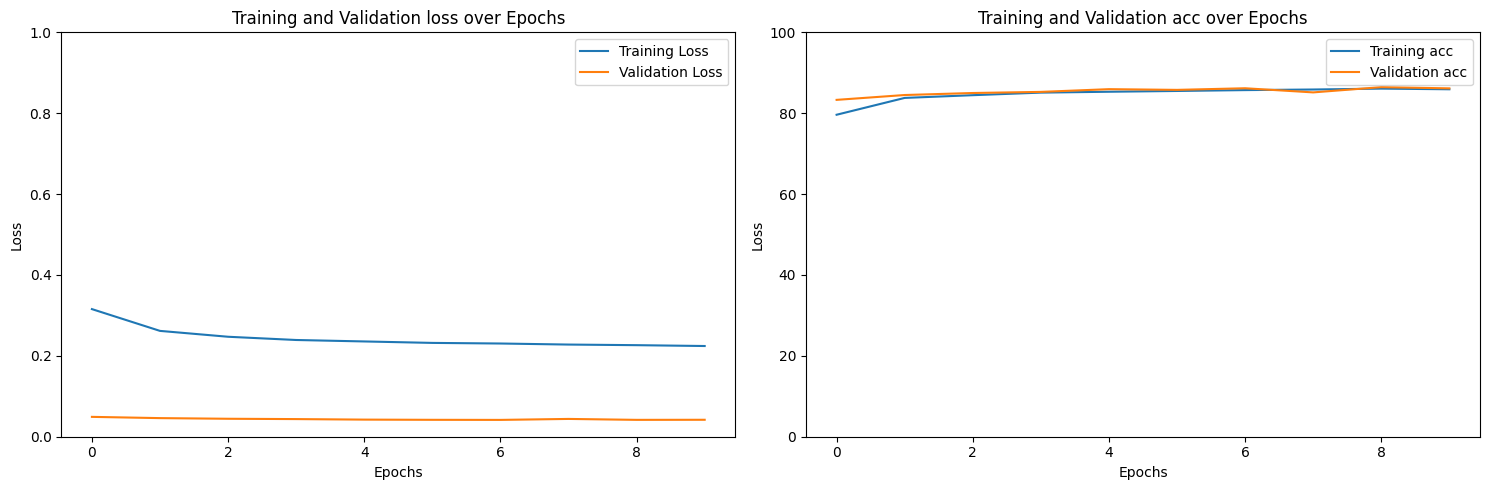

In [ ]:
fig , axs = plt.subplots(1,2, figsize=(15,5))

axs[0].plot(total_loss_train_plot , label="Training Loss")
axs[0].plot(total_loss_val_plot , label="Validation Loss")
axs[0].set_title("Training and Validation loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_ylim([0,1])
axs[0].legend()

axs[1].plot(total_acc_train_plot , label="Training acc")
axs[1].plot(total_acc_val_plot , label="Validation acc")
axs[1].set_title("Training and Validation acc over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].set_ylim([0,100])
axs[1].legend()

plt.tight_layout()
plt.show()

# **9-Save model**

In [ ]:
from google.colab import files

filename = 'sarcasm_detection.pth'

torch.save(model.state_dict(), filename)

files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>